# 04 — Dynamometer Card (Load vs Position)

**Notebook focus:** answer Q7–Q8 by building surface dynamometer cards, then using
shape evidence plus time evidence to curate and interpret the anomalous rounds.

## Contents
1. Estimate pump frequency
2. Extract a representative card
3. Explain the physical meaning of the loop
4. Summarise expected gas / mechanical shape changes
5. Sanity-check the load signal
6. Extract all cards and inspect cross-time stability
7. Convert each card into interpretable metrics
8. Build the Q8 anomaly taxonomy and gallery
9. Show the time evidence as animations
10. Quantify how often anomalous rounds worsen within the round
11. Record how the era references are validated in nb05


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from well_analysis.data import load_test_data
from well_analysis.signal import check_even_sampling, transient_mask
from well_analysis.signal.integration import integrate_acceleration, estimate_gravity_offset
from well_analysis.detection import detect_well_state
from well_analysis.analysis.dynamometer import (
    estimate_pump_frequency, extract_dynamometer_cards, estimate_stroke_amplitude
)
from well_analysis.viz import plot_dynamometer_card

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = load_test_data()
_, fs = check_even_sampling(df['Timestamp'])
accel = df['Acceleration'].values
load  = df['Load'].values

is_running = detect_well_state(accel, fs=fs)
g_offset   = estimate_gravity_offset(accel, is_running)
_, position = integrate_acceleration(accel, fs=fs, gravity_offset=g_offset)

valid_mask = transient_mask(is_running, fs=fs, hp_cutoff=0.04)

## 1. Estimate pump frequency

**Takeaway:** the pump frequency is stable enough to use one consistent cycle-segmentation setting across the record.

In [2]:
# Use only running samples for clean spectral estimate
pump_freq = estimate_pump_frequency(accel[is_running], fs=fs)
print(f"Pump frequency: {pump_freq:.4f} Hz  (period = {1/pump_freq:.1f} s)")

Pump frequency: 0.1000 Hz  (period = 10.0 s)


## 2. Extract individual cards and plot a representative one (Q7)

**Takeaway:** a single representative card establishes the baseline loop we will compare against later.

In [3]:
# Use a short running window (e.g. ~5 minutes) for the showcase card
# TODO: update window after exploring the dataset
t_start = pd.Timestamp('2020-12-25T02:01:00', tz='UTC')
t_end   = t_start + pd.Timedelta(minutes=5)
mask = (df['Timestamp'] >= t_start) & (df['Timestamp'] < t_end) & is_running

pos_w  = position[mask]
load_w = load[mask]

cards = extract_dynamometer_cards(pos_w, load_w, fs=fs, pump_freq=pump_freq)
print(f"Extracted {len(cards)} cycles in window")

Extracted 29 cycles in window


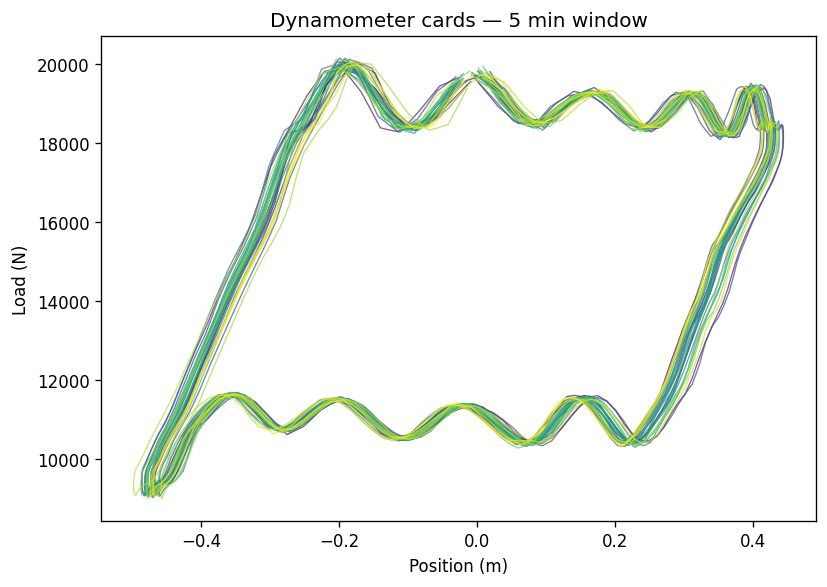

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
# Overlay all cards in window, colour by cycle index
colours = cm.viridis(np.linspace(0, 1, len(cards)))
for i, card in enumerate(cards):
    ax.plot(card['pos'], card['load'], lw=0.8, color=colours[i], alpha=0.7)
ax.set_xlabel('Position (m)')
ax.set_ylabel('Load (N)')
ax.set_title('Dynamometer cards — 5 min window')
plt.tight_layout()
plt.show()

## 3. Physical significance (Q7)

**Takeaway:** each edge of the card has physical meaning, so later shape changes can be tied back to plausible mechanisms.


The dynamometer card (load vs position) is the standard diagnostic for rod pump health:

- **Top edge (upstroke)**: polished rod carries fluid weight + rod buoyancy − friction → high load plateau.
- **Bottom edge (downstroke)**: fluid weight transferred to tubing via standing valve → low load.
- **Right rise** (bottom-stroke to top): standing valve opens, travelling valve closes.
- **Left drop** (top to bottom): travelling valve opens, standing valve closes.
- **Card area** ∝ net work done per stroke ∝ fluid production.

Deviations from the ideal parallelogram indicate:
- **Rounded corners / reduced area** → gas interference / incomplete fillage
- **Inverted or collapsed card** → rod string buckling or valve failure
- **Asymmetry** → paraffin build-up, mechanical friction

## 4. Effect of gas/liquid ratio and mechanical failures (Q8)

**Takeaway:** Q8 is treated as a diagnostic interpretation problem, not a definitive fault-classification problem.


*(Discuss after visualising multiple time windows below)*

| Condition | Card shape change |
|-----------|------------------|
| High gas / low fillage | Rounded bottom right corner; reduced upper plateau; card area shrinks |
| Fluid pound (pump hits liquid surface) | Sudden spike at bottom of upstroke |
| Worn travelling valve | Upper load line drops during upstroke |
| Worn standing valve | Lower load line rises during downstroke |
| Paraffin / tubing hole | Altered load baseline |

---
# Evidence for Q8 — what the 21 days actually show

§ 1–§ 4 answer **Q7** (one representative card + physical interpretation) and
state Q8 in theory. Q8 asks us to **diagnose**: show a few cards that look
different, describe the differences in physical terms, and form hypotheses.

**Scope note.** Q8 is *diagnostic*, not *classification*. Our job here is a
magnifying glass: "which cards should a human look at, and what could each
one be?" — not "auto-label every card into a taxonomy". The latter is Q9/Q10
and lives in notebook 05.

**Methodology boundary.** We analyse the **surface card** (polished-rod load
vs reconstructed position). Commercial rod-pump diagnostics (Gibbs 1963,
Weatherford eXpert, Lufkin SAM) usually solve the 1-D rod-string wave
equation to recover the downhole **pump card**, which shows the actual valve
behaviour. That requires rod-string geometry (segment lengths, diameters,
damping), which the case study does not provide. Surface cards carry
rod-string dynamics on top of pump behaviour, so some features we see may be
reconstruction artefacts rather than pump events — we flag these when
relevant.

## 5. Load signal — basic EDA

**Takeaway:** the load channel already separates stopped and running behaviour, so the card analysis rests on a physically informative signal.


Before reading card shape, verify the load signal itself:
- stopped segments → nearly constant hanging weight (rod + bob in air),
- running segments → periodic oscillation around a higher mean.

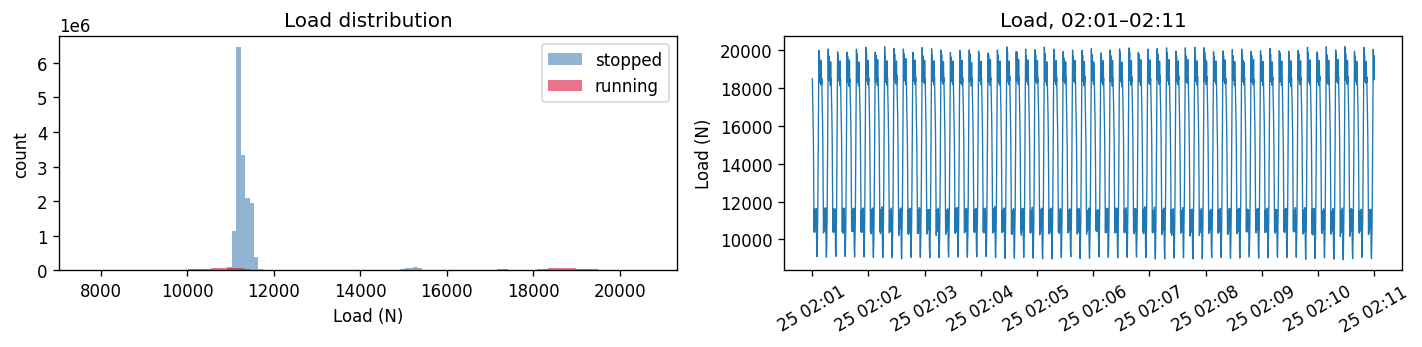

Stopped: mean= 11396.3 N   std= 674.0 N  (hanging weight)
Running: mean= 15001.3 N   std=3546.5 N
Δ(running − stopped) ≈ 3605 N  (fluid load)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(load[~is_running], bins=100, alpha=0.6, label='stopped', color='steelblue')
axes[0].hist(load[is_running],  bins=100, alpha=0.6, label='running', color='crimson')
axes[0].set_xlabel('Load (N)'); axes[0].set_ylabel('count'); axes[0].legend()
axes[0].set_title('Load distribution')

t0 = pd.Timestamp('2020-12-25T02:01:00', tz='UTC')
t1 = pd.Timestamp('2020-12-25T02:11:00', tz='UTC')
m = (df['Timestamp'] >= t0) & (df['Timestamp'] < t1)
axes[1].plot(df['Timestamp'][m], load[m], lw=0.8)
axes[1].set_ylabel('Load (N)'); axes[1].set_title('Load, 02:01–02:11')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print(f'Stopped: mean={load[~is_running].mean():8.1f} N   std={load[~is_running].std():6.1f} N  (hanging weight)')
print(f'Running: mean={load[is_running].mean() :8.1f} N   std={load[is_running].std() :6.1f} N')
print(f'Δ(running − stopped) ≈ {load[is_running].mean() - load[~is_running].mean():.0f} N  (fluid load)')

## 6. Cross-time card overlay — shape stability over 21 days

**Takeaway:** after tightening the extraction pipeline, the remaining overlay spread is more likely to reflect real shape variation than reconstruction artefacts.


Since § 5 the integration pipeline was tightened (L2 fix):
- `hp_cutoff` raised 0.02 → 0.04 Hz (still ≥ 2.5× below pump frequency),
- a `transient_mask` excludes the first/last ≈ 40 s of every running
  segment (where the high-pass output carries contamination from the
  neighbouring stopped region),
- `segment_cycles` now detrends locally over 5 pump periods before
  finding zero-crossings.

Together these cut stroke-length CV from 4.8 % to 2.2 % and p90-load CV
from 1.7 % to 0.7 %. Cycles that previously looked like shape anomalies
but were really integration boundary transients now correctly drop out.

Each card is still shown recentered (position − P50, load − P50) so the
remaining overlay spread reflects *shape* differences only.

Extracted 18,133 cards from 219 timer_on segments.


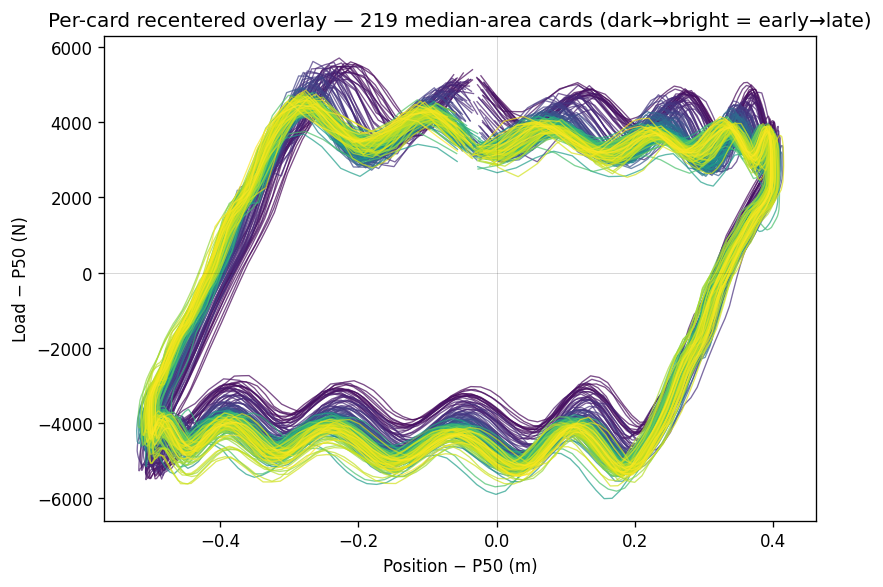

In [6]:
from well_analysis.detection import cluster_segments_by_duration, classify_controller_mode
from well_analysis.analysis.q8 import (
    build_card_metric_frame,
    extract_cards_with_metrics,
    select_segment_median_area_cards,
)

# Q8 data backbone:
#   1) identify timer_on segments,
#   2) extract every card once,
#   3) attach interpretable metrics,
#   4) keep one median-area representative per round for the cross-time overlay.
segs = classify_controller_mode(df['Timestamp'], is_running)
seg_c, _ = cluster_segments_by_duration(segs)
timer_on = seg_c[seg_c['cluster_label'] == 'timer_on'].reset_index(drop=True)

ts_arr = df['Timestamp'].values.astype('datetime64[ns]')
all_cards = extract_cards_with_metrics(
    timer_on=timer_on,
    timestamps_ns=ts_arr,
    position=position,
    load=load,
    fs=fs,
    pump_freq=pump_freq,
    valid_mask=valid_mask,
)
dm = build_card_metric_frame(all_cards)
print(f'Extracted {len(all_cards):,} cards from {len(timer_on)} timer_on segments.')

daily_cards = select_segment_median_area_cards(all_cards, dm, timer_on['start'])

fig, ax = plt.subplots(figsize=(7, 5))
colours = cm.viridis(np.linspace(0, 1, len(daily_cards)))
for (t, c), col in zip(daily_cards, colours):
    p = c['pos'] - np.median(c['pos'])
    l = c['load'] - np.median(c['load'])
    ax.plot(p, l, lw=0.8, color=col, alpha=0.7)
ax.set_xlabel('Position − P50 (m)')
ax.set_ylabel('Load − P50 (N)')
ax.set_title(f'Per-card recentered overlay — {len(daily_cards)} median-area cards (dark→bright = early→late)')
ax.axhline(0, color='k', lw=0.3, alpha=0.3)
ax.axvline(0, color='k', lw=0.3, alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Shape metrics over time — multi-dimensional filter

**Takeaway:** these metrics turn each card into a small interpretable feature vector for filtering, scoring, and explanation.


We track four **shape** metrics and two **QC** metrics per card:

Shape (used for anomaly selection in §8):
- **area** — net work per stroke
- **stroke length** = P99 − P1 of position (should be mechanically fixed)
- **P10 load** — lower plateau (standing-valve side)
- **P90 load** — upper plateau (travelling-valve side)
- **asym_tilt** — polygon centroid horizontal offset / stroke.
  0 = symmetric card; non-zero = upstroke-heavy or downstroke-heavy.
  Sensitive to friction / paraffin / drag that aren't captured by
  plateau-load metrics.

QC (used for the Layer-1 trust filter in §8, **not** for anomaly hunting):
- **gap_frac** = |pos[start] − pos[end]| / stroke. Large value = cycle
  boundary was displaced by residual drift → segmentation suspect.

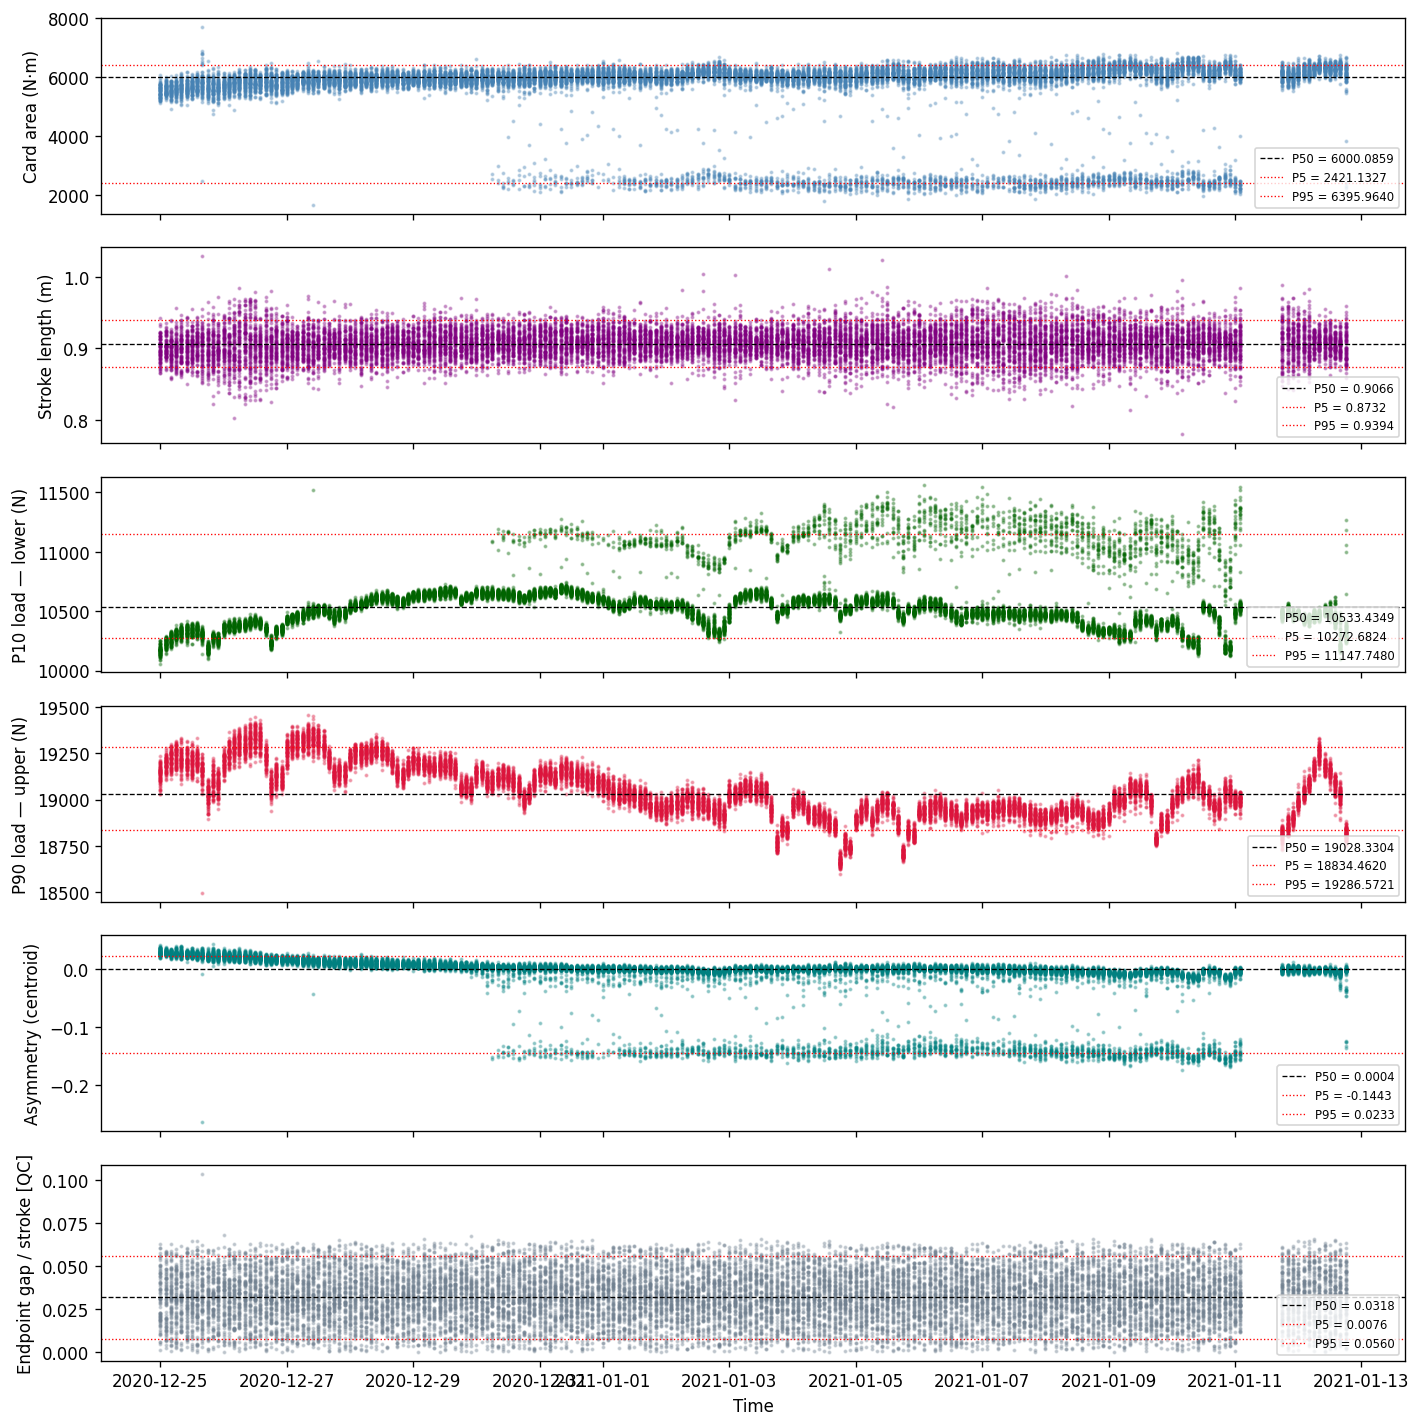

Metric summary (median / P5 / P95 / CV):
  area      : P50= 6000.0859   P5= 2421.1327   P95= 6395.9640   CV=0.2004
  stroke    : P50=    0.9066   P5=    0.8732   P95=    0.9394   CV=0.0225
  p10_load  : P50=10533.4349   P5=10272.6824   P95=11147.7480   CV=0.0220
  p90_load  : P50=19028.3304   P5=18834.4620   P95=19286.5721   CV=0.0074
  asym_tilt : P50=    0.0004   P5=   -0.1443   P95=    0.0233   CV=3.6204
  gap_frac  : P50=    0.0318   P5=    0.0076   P95=    0.0560   CV=0.4516


In [7]:
fig, axes = plt.subplots(6, 1, figsize=(12, 12), sharex=True)
specs = [('area',      'Card area (N·m)',        'steelblue',  False),
         ('stroke',    'Stroke length (m)',      'purple',     False),
         ('p10_load',  'P10 load — lower (N)',   'darkgreen',  False),
         ('p90_load',  'P90 load — upper (N)',   'crimson',    False),
         ('asym_tilt', 'Asymmetry (centroid)',   'teal',       False),
         ('gap_frac',  'Endpoint gap / stroke',  'slategray',  True)]
for ax, (col, ylabel, colour, is_qc) in zip(axes, specs):
    ax.scatter(dm['t'], dm[col], s=2, alpha=0.3, color=colour)
    m50 = dm[col].median(); m05 = dm[col].quantile(0.05); m95 = dm[col].quantile(0.95)
    ax.axhline(m50, ls='--', color='k',   lw=0.8, label=f'P50 = {m50:.4f}')
    ax.axhline(m05, ls=':',  color='red', lw=0.8, label=f'P5 = {m05:.4f}')
    ax.axhline(m95, ls=':',  color='red', lw=0.8, label=f'P95 = {m95:.4f}')
    tag = ' [QC]' if is_qc else ''
    ax.set_ylabel(ylabel + tag); ax.legend(loc='lower right', fontsize=7)
axes[-1].set_xlabel('Time')
plt.tight_layout(); plt.show()

print('Metric summary (median / P5 / P95 / CV):')
for col, *_ in specs:
    v = dm[col]
    cv = v.std()/abs(v.mean()) if v.mean() else float('nan')
    print(f'  {col:10s}: P50={v.median():10.4f}   P5={v.quantile(0.05):10.4f}'
          f'   P95={v.quantile(0.95):10.4f}   CV={cv:.4f}')


## 8. Anomaly taxonomy via a 3-layer decision framework

**Takeaway:** the anomaly gallery is built in three layers: confidence tagging, era-specific references, and temporal evidence.


We replaced the earlier hand-crafted A/B/C/D families with an
**unsupervised 3-layer pipeline** motivated by the Q9/Q10 findings in nb05
(regime taxonomy + the 12-31 era shift).

**Layer 1 — confidence tag, not a hard filter.**
Cards with `|stroke − median|/median ≥ 10 %` or `gap_frac ≥ P95` are
tagged **low-confidence** but *not discarded*.  The Isolation Forest is
still trained only on the high-confidence subset (so "normal" is not
polluted by reconstruction glitches), but **per-round argmax is allowed
to pick from all 18,133 cards**.  A high-gap card that reproduces across
multiple rounds is more likely to reflect a reproducible mechanical
shape than an independent reconstruction artefact — we give Layer 3 a
chance to rescue it, but we do not claim this is certain.  A systematic
reconstruction pipeline failure triggered by a recurring controller
state could in principle mimic the same pattern.

**Layer 2 — per-era visual reference for the gallery.**
nb05 §10 found a one-way regime shift at 2020-12-31 / 2021-01-01 —
cluster 2 dominates 12-25..12-30, cluster 0 dominates 01-01 onward.
A single 21-day "typical" card would not look like either era.  We
therefore build **two reference cards**, one per era, each from the
inlier core (trusted cards whose IF score is below the within-era P50)
as a point-wise median on recentered shapes.  These references are used
**only as the black comparison curve** in the gallery panels below —
they are *not* inputs to the anomaly scoring.

Scoring is deliberately **global**, not era-conditioned:

- **One** Isolation Forest trained on the full trusted subset.
- Per-round argmax across all cards (any confidence).
- **Global** P99 threshold on the IF score distribution.

A per-era IF would require choosing what to do with cards whose score
is high only relative to their own era — since the 12-31 shift is a
real operational change, we want those cards to surface, so we keep a
single global score distribution.

**Layer 3 — classify each candidate into fluid / mechanical / uncertain.**

| Trigger | Category | Physical hypothesis |
|---|---|---|
| `Kendall τ ≥ 0.2` on (card_index, IF_score) *within the round* AND dominant feature ∈ {`area`, `upstroke_heaviness`, `p90_load`} | **fluid / gas-interference-like** | Progressive within-round degradation, loss of area / upper plateau — fluid pound or gas interference hypothesis |
| Shape cluster (channel-normalised L2 on recentered curves) spans ≥ 3 distinct rounds AND dominant feature ∈ {`asym_tilt`, `p10_load`, `load_median`} | **mechanical-like** | Persistent edge distortion that repeats across rounds — friction / drag / valve wear hypothesis |
| **High gap_frac AND shape cluster spans ≥ 3 rounds** | **mechanical-like (rescued)** | Repeating non-closed shape — interpreted as a likely mechanical signature rather than a reconstruction glitch, since independent rounds would not share the same artefact pattern |
| Anything else | **uncertain** | Isolated single-round event or ambiguous combination — honestly flag |

Shape-distance clustering uses pairwise L2 on the 400-dim (pos + load)
recentered curves, with each channel independently scaled by its own
std so the load channel (≈ 10⁴ N) does not dominate the position
channel (≈ 1 m) 10 000:1.  Agglomerative average-linkage, distance
threshold = **P5 of all pairwise distances** — deliberately tight, so
"multi-round cluster" means a genuinely reproducible shape rather than
"within the normal blob".  An earlier P25 threshold produced spurious
mega-clusters containing almost all candidates; P5 recovers the
distinction we want.

The gallery panels are coloured by Layer-3 category, not by
`dom_feature`.  A summary figure below the gallery shows one medoid
card per (era × category) cell.

Layer 1:  17,219 / 18,133 (95.0%) high-confidence.
          gap threshold P95 = 0.056.  Low-confidence cards are kept, only tagged.



IF trained on 17,219 trusted cards, scored all 18,133.
IF score range = [0.363, 0.725], median = 0.417
Spearman rho(IF, MAD-Mahalanobis) on all cards = 0.977  (>0.7 = consistent).

Era 0 (≤ 2020-12-31 23:59:59+00:00):  6,972 cards
Era 1 (> 2020-12-31 23:59:59+00:00):  11,161 cards
  era 0 inlier core = 3,316 cards → pointwise-median reference
  era 1 inlier core = 5,294 cards → pointwise-median reference

Stage 1:  219 candidates (one per round, any confidence allowed).
Stage 2:  P99.0 threshold = 0.648, gallery = 100 cards.



Layer 3a:  83 / 100 gallery rounds show τ ≥ 0.2.
Layer 3b:  40 shape clusters, 197 candidates in ≥3-round clusters.
           distance threshold (pairwise P5) = 1.55

Category counts (gallery):
category
mechanical    65
fluid         20
uncertain     15

  · fluid    = same-round worsening + fluid-tag features
  · mechanical = multi-round shape cluster + mechanical features (or gap-rescued)
  · uncertain = anything else


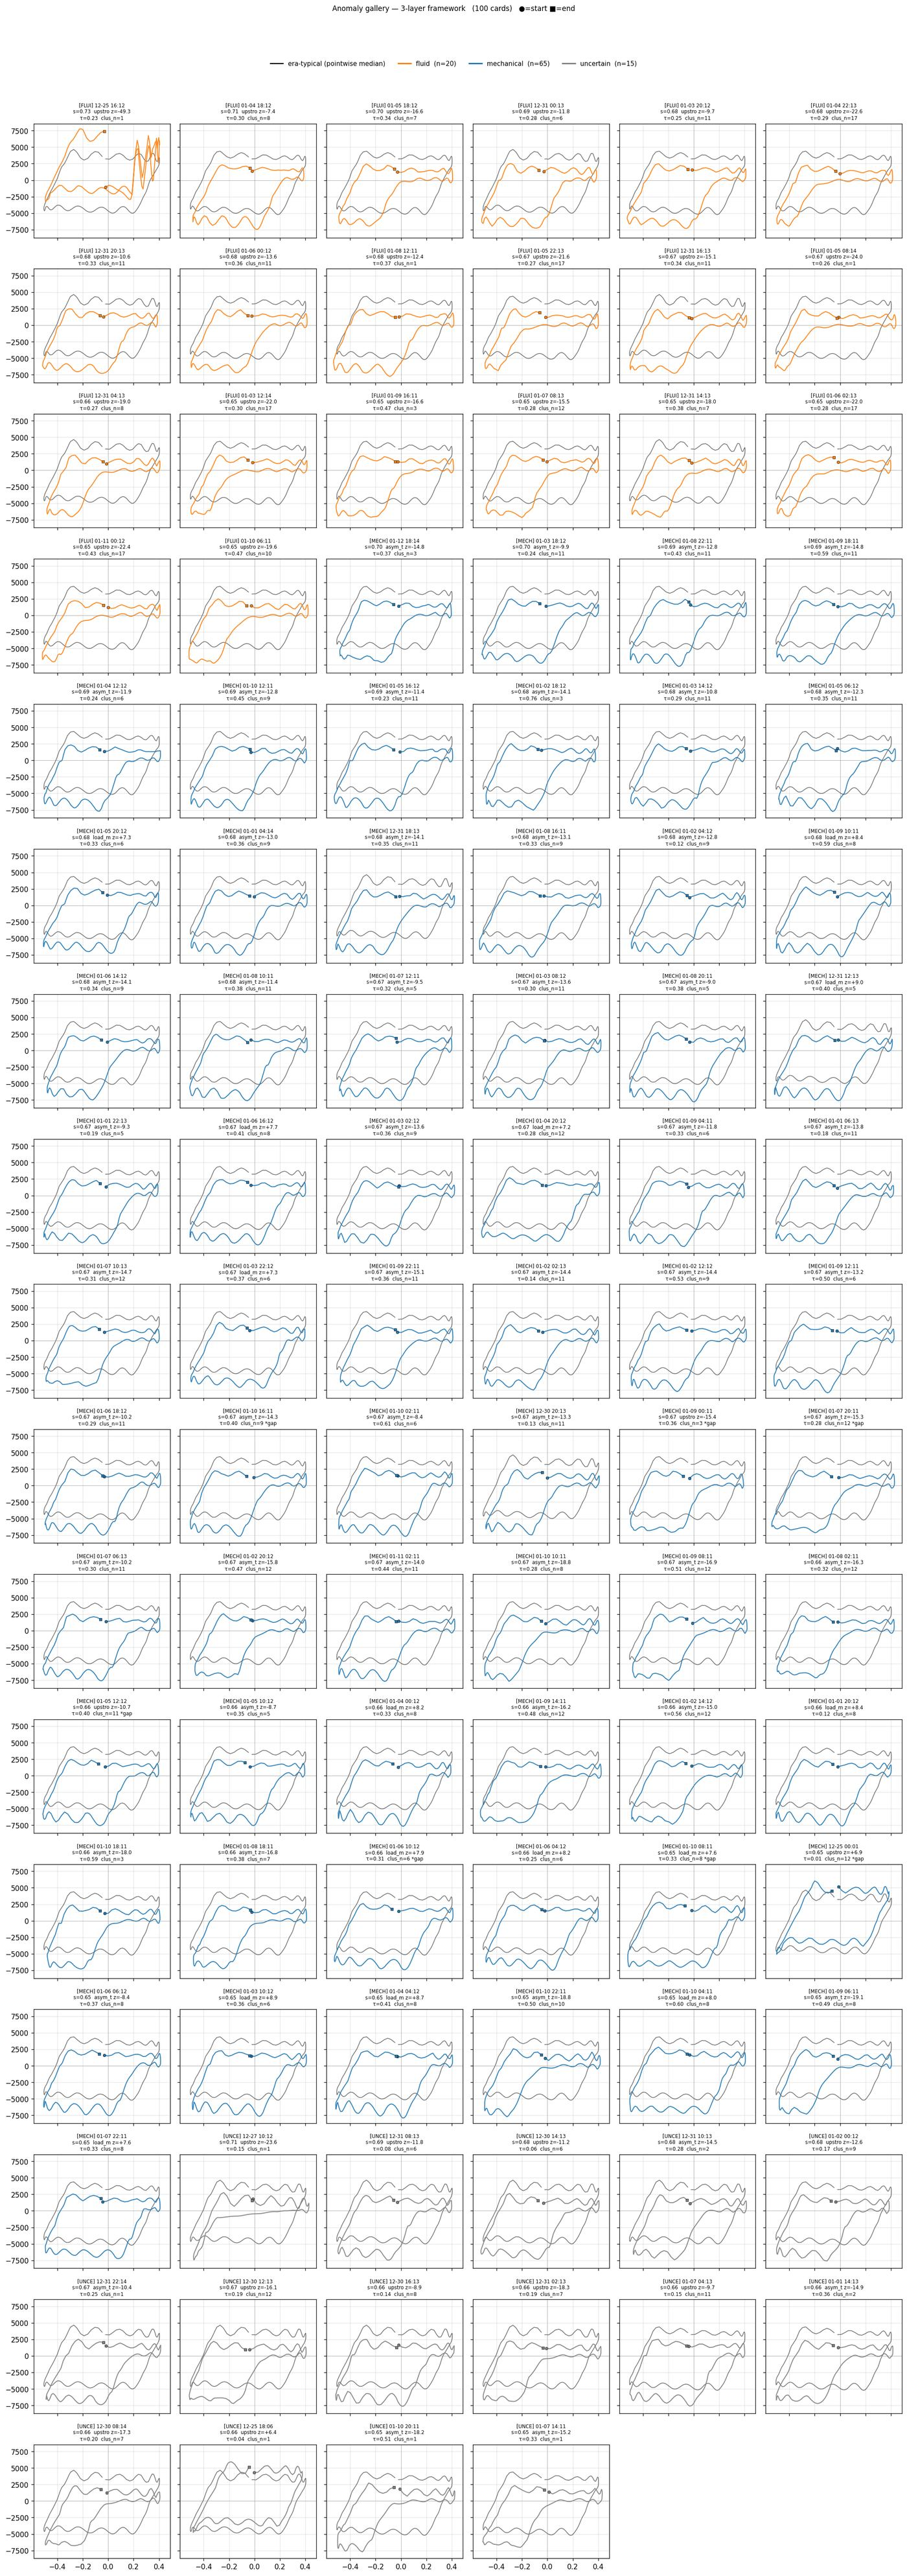

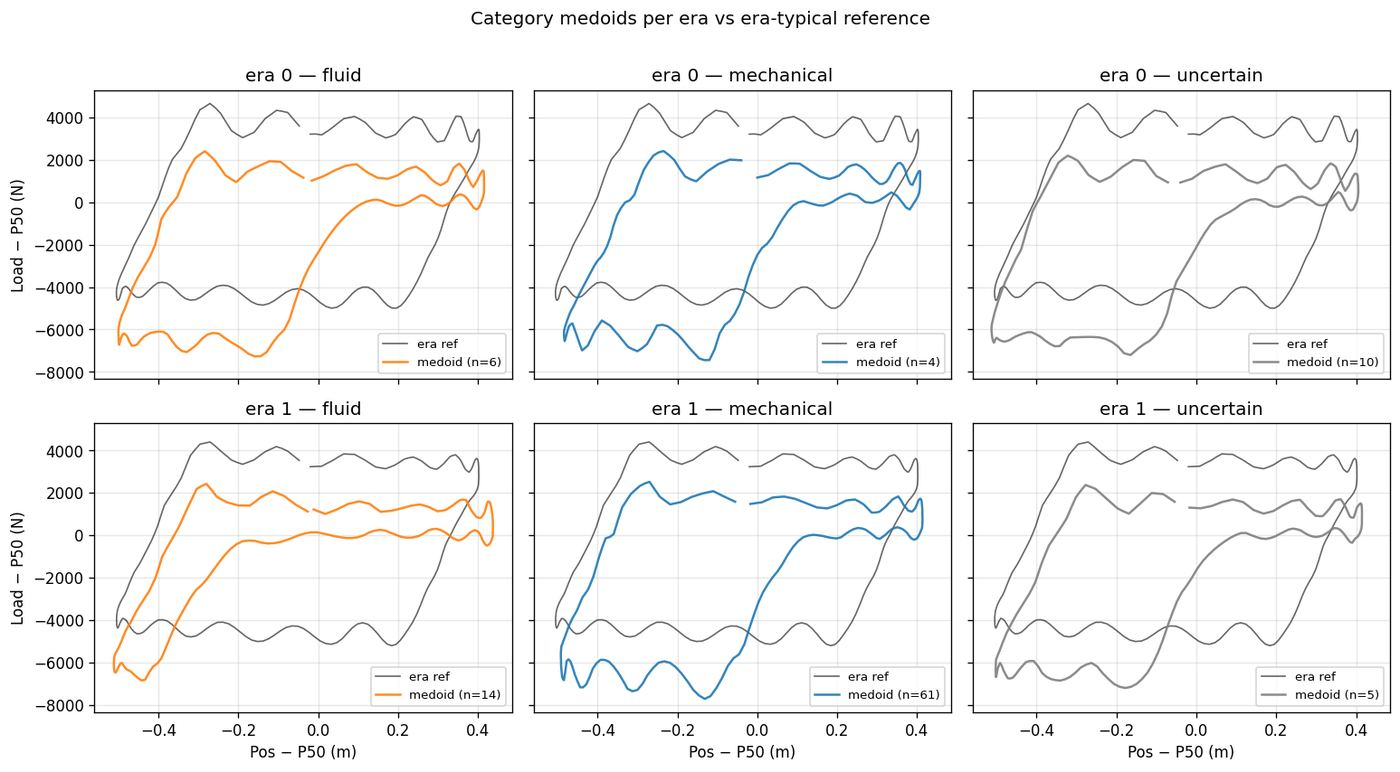


Run summary: {'n_trusted': 17219, 'rho': 0.9769099536613653, 'thr': 0.6481201980000052, 'n_gallery': 100, 'worsening_ct': 83, 'multi_round_ct': 90, 'by_cat': {'mechanical': 65, 'fluid': 20, 'uncertain': 15}, 'by_era': {(0, 'fluid'): 6, (0, 'mechanical'): 4, (0, 'uncertain'): 10, (1, 'fluid'): 14, (1, 'mechanical'): 61, (1, 'uncertain'): 5}}


In [8]:
from sklearn.ensemble import IsolationForest
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from well_analysis.analysis.clustering import FEATURE_NAMES
from well_analysis.analysis.q8 import (
    build_era_references,
    build_round_candidate_frame,
    build_trusted_subset,
    cluster_candidate_shapes,
    compute_round_taus,
    dominant_feature_info,
    fit_global_anomaly_scores,
    select_gallery_candidates,
)

# ============================================================
# Layer 1 — confidence tag (NO drop)
# ============================================================
# Keep the trust rule visible in the notebook: low stroke deviation + good loop closure.
stroke_dev, gap_thresh, trusted_mask, trusted_idx = build_trusted_subset(dm)
trusted_cards = [all_cards[i] for i in trusted_idx]
print(f'Layer 1:  {trusted_mask.sum():,} / {len(dm):,} ({100*trusted_mask.mean():.1f}%) high-confidence.')
print(f'          gap threshold P95 = {gap_thresh:.3f}.  Low-confidence cards are kept, only tagged.')

# ============================================================
# Global anomaly score — IF on trusted cards, MAD-z cross-check on all cards
# ============================================================
X_trust, X_all, if_all, Z_all, rho = fit_global_anomaly_scores(trusted_cards, all_cards)
print()
print(f'IF trained on {len(X_trust):,} trusted cards, scored all {len(X_all):,}.')
print(f'IF score range = [{if_all.min():.3f}, {if_all.max():.3f}], median = {np.median(if_all):.3f}')
print(f'Spearman rho(IF, MAD-Mahalanobis) on all cards = {rho:.3f}  (>0.7 = consistent).')

# ============================================================
# Era split and visual references
# ============================================================
card_t = pd.to_datetime([c['t'] for c in all_cards])
ERA_SPLIT = pd.Timestamp('2020-12-31 23:59:59', tz=card_t.tz) if card_t.tz is not None else pd.Timestamp('2020-12-31 23:59:59')
era_id, era_ref, card_t = build_era_references(all_cards, trusted_mask, if_all, ERA_SPLIT)
print()
print(f'Era 0 (≤ {ERA_SPLIT}):  {np.sum(era_id==0):,} cards')
print(f'Era 1 (> {ERA_SPLIT}):  {np.sum(era_id==1):,} cards')
for era in [0, 1]:
    in_era = (era_id == era) & trusted_mask
    p50_scr = np.percentile(if_all[in_era], 50)
    core = np.where(in_era & (if_all <= p50_scr))[0]
    print(f'  era {era} inlier core = {len(core):,} cards → pointwise-median reference')

# ============================================================
# Stage 1 / Stage 2 — one candidate per round, then global P99 gallery cut
# ============================================================
df_all, candidates = build_round_candidate_frame(
    all_cards=all_cards,
    era_id=era_id,
    if_all=if_all,
    gap_frac=dm['gap_frac'].values,
    trusted_mask=trusted_mask,
)
print()
print(f'Stage 1:  {len(candidates)} candidates (one per round, any confidence allowed).')

THRESH_Q = 0.99
gallery, threshold = select_gallery_candidates(candidates, if_all, threshold_q=THRESH_Q)
print(f'Stage 2:  P{THRESH_Q*100:.1f} threshold = {threshold:.3f}, gallery = {len(gallery)} cards.')

# ============================================================
# Layer 3a / 3b — temporal evidence inside rounds and across rounds
# ============================================================
round_tau = compute_round_taus(df_all)
gallery['tau'] = gallery['round_t'].map(round_tau)
gallery['worsening'] = gallery['tau'].fillna(-1) >= 0.2
print()
print(f'Layer 3a:  {gallery["worsening"].sum()} / {len(gallery)} gallery rounds show τ ≥ 0.2.')

candidates, dist_thr = cluster_candidate_shapes(candidates, all_cards, distance_quantile=0.05)
info = candidates.set_index('all_idx')[['shape_cluster', 'n_rounds_in_cluster']]
gallery = gallery.merge(info, left_on='all_idx', right_index=True, how='left')
print(f'Layer 3b:  {candidates["shape_cluster"].nunique()} shape clusters, '
      f'{(candidates["n_rounds_in_cluster"] >= 3).sum()} candidates in ≥3-round clusters.')
print(f'           distance threshold (pairwise P5) = {dist_thr:.2f}')

# Dominant feature = which robust-z axis explains most of a card's anomaly score.
dominfo = dominant_feature_info(Z_all, gallery['all_idx'], FEATURE_NAMES)
gallery['dom_feature'] = [d[0] for d in dominfo]
gallery['dom_z'] = [d[1] for d in dominfo]

# ============================================================
# Final categorisation
# ============================================================
FLUID_TAGS = {'area', 'upstroke_heaviness', 'p90_load'}
MECH_TAGS = {'asym_tilt', 'p10_load', 'load_median'}

def classify(r):
    high_gap = r['gap_frac'] >= gap_thresh
    multi_round = r['n_rounds_in_cluster'] >= 3
    if high_gap and multi_round:
        return 'mechanical'
    if r['worsening'] and r['dom_feature'] in FLUID_TAGS:
        return 'fluid'
    if multi_round and r['dom_feature'] in MECH_TAGS:
        return 'mechanical'
    return 'uncertain'

gallery['category'] = gallery.apply(classify, axis=1)
print()
print('Category counts (gallery):')
print(gallery['category'].value_counts().to_string())
print()
print('  · fluid    = same-round worsening + fluid-tag features')
print('  · mechanical = multi-round shape cluster + mechanical features (or gap-rescued)')
print('  · uncertain = anything else')

# ============================================================
# Gallery + per-era medoids remain in the notebook so the result stays readable.
# ============================================================

# ============================================================
# GALLERY PLOT — coloured by category
# ============================================================
CAT_COLOURS = {'fluid': 'tab:orange', 'mechanical': 'tab:blue', 'uncertain': 'tab:gray'}
gs = gallery.sort_values(['category','if'], ascending=[True, False]).reset_index(drop=True)
n_g = len(gs); cols = 6
rows = max(1, (n_g + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(3.0*cols, 2.9*rows), sharex=True, sharey=True)
axes = np.atleast_2d(axes).flatten()

for k, (ax, (_, row)) in enumerate(zip(axes, gs.iterrows())):
    c = all_cards[int(row['all_idx'])]
    p_a = c['pos']  - np.median(c['pos'])
    l_a = c['load'] - np.median(c['load'])
    p_ref, l_ref = era_ref[int(row['era'])]
    col = CAT_COLOURS[row['category']]

    ax.plot(p_ref, l_ref, lw=1.0, color='black', alpha=0.55)
    ax.plot(p_a,   l_a,   lw=1.3, color=col,     alpha=0.90)
    ax.plot(p_a[0],  l_a[0],  'o', color=col, ms=4, mec='k', mew=0.4)
    ax.plot(p_a[-1], l_a[-1], 's', color=col, ms=4, mec='k', mew=0.4)

    t_card = pd.Timestamp(c['t']) + pd.Timedelta(seconds=c['start']/fs)
    gap_flag = ' *gap' if row['gap_frac'] >= gap_thresh else ''
    ax.set_title(
        f"[{row['category'][:4].upper()}] {t_card.strftime('%m-%d %H:%M')}\n"
        f"s={row['if']:.2f}  {row['dom_feature'][:6]} z={row['dom_z']:+.1f}\n"
        f"τ={row['tau']:.2f}  clus_n={int(row['n_rounds_in_cluster'])}{gap_flag}",
        fontsize=7)
    ax.axhline(0, color='gray', lw=0.3); ax.axvline(0, color='gray', lw=0.3)
    ax.grid(alpha=0.3)
for ax in axes[n_g:]: ax.axis('off')

handles = [Line2D([0],[0], color='black', lw=1.5, label='era-typical (pointwise median)')]
for cat, col in CAT_COLOURS.items():
    nc = int((gs['category'] == cat).sum())
    handles.append(Line2D([0],[0], color=col, lw=2, label=f'{cat}  (n={nc})'))
fig.legend(handles=handles, loc='upper center', ncol=len(handles),
           bbox_to_anchor=(0.5, 1.01), fontsize=9, frameon=False)
plt.suptitle(
    f'Anomaly gallery — 3-layer framework   ({len(gs)} cards)   ●=start ■=end',
    y=1.03, fontsize=10)
plt.tight_layout(); plt.show()

# ============================================================
# Summary figure — one medoid per (era × category)
# ============================================================
fig2, axes2 = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ci, cat in enumerate(['fluid','mechanical','uncertain']):
    for era in [0, 1]:
        ax  = axes2[era, ci]
        sub = gs[(gs['category'] == cat) & (gs['era'] == era)]
        p_ref, l_ref = era_ref[era]
        ax.plot(p_ref, l_ref, lw=1.0, color='black', alpha=0.6, label='era ref')
        if len(sub) == 0:
            ax.text(0.5, 0.5, f'no {cat} cards\nin era {era}',
                    transform=ax.transAxes, ha='center', va='center', color='gray')
        else:
            # medoid = card with median IF score inside this bin
            medoid = sub.iloc[len(sub)//2]
            c  = all_cards[int(medoid['all_idx'])]
            p_a = c['pos']  - np.median(c['pos'])
            l_a = c['load'] - np.median(c['load'])
            ax.plot(p_a, l_a, lw=1.5, color=CAT_COLOURS[cat], alpha=0.9,
                    label=f'medoid (n={len(sub)})')
        ax.set_title(f'era {era} — {cat}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
for ax in axes2[-1, :]: ax.set_xlabel('Pos − P50 (m)')
for ax in axes2[:,  0]: ax.set_ylabel('Load − P50 (N)')
plt.suptitle('Category medoids per era vs era-typical reference', y=1.01)
plt.tight_layout(); plt.show()

# Persist summary for narrative
_summary = dict(
    n_trusted = int(trusted_mask.sum()),
    rho       = float(rho),
    thr       = float(threshold),
    n_gallery = int(len(gallery)),
    worsening_ct = int(gallery['worsening'].sum()),
    multi_round_ct = int((gallery['n_rounds_in_cluster'] >= 3).sum()),
    by_cat    = gallery['category'].value_counts().to_dict(),
    by_era    = gallery.groupby(['era','category']).size().to_dict(),
)
print('\nRun summary:', _summary)

### Run summary (from cell 17)

- **Layer 1**: 17,219 / 18,133 (95.0 %) high-confidence.  Low-confidence cards are kept, not dropped.
- **IF vs MAD-Mahalanobis** Spearman ρ = **0.977** on all 18 k cards — the two anomaly definitions agree on ranking almost perfectly, so the gallery is not a method artefact.
- **P99 gallery**: 100 / 219 timer_on rounds qualify (their argmax card beats the P99 of all-card IF scores).
- **Kendall τ ≥ 0.2** (within-round worsening): 83 / 100 rounds.
- **Shape clusters**: 40 clusters on the channel-normalised curves; 90 / 100 gallery cards sit in a cluster that spans ≥ 3 distinct rounds.
- **Category split**: 65 mechanical-like · 20 fluid-like · 15 uncertain.
- **By era**:
  - Era 0 (12-25..12-30): 4 mechanical · 6 fluid · 10 uncertain — anomaly structure is weak / noisy.
  - Era 1 (01-01..01-12): **61 mechanical** · 14 fluid · 5 uncertain — dominated by a reproducible shape.

### The headline finding

The three per-era category medoids all look like **the same left-tilted, compressed loop** — only the era-reference background differs.  In plain words:

> **This well has one dominant anomaly shape.  The 3-layer framework
>  does not separate it into different faults by shape — it separates
>  the same shape by the *temporal evidence* under it:**
>
> - If the shape appeared gradually within a single round →  *fluid-like*
> - If the shape reappears across ≥ 3 rounds →  *mechanical-like*
> - If neither →  *uncertain*

This is consistent with nb05: the unsupervised clustering also found
only **one** anomaly basin (cluster 1), rather than several distinct
anomaly prototypes.  A single well with a single dominant anomaly does
not support a multi-fault taxonomy no matter how many labels we write.

### What the era split reveals

Era 1 contains 61 / 65 of the mechanical-like cards — **94 % of the
cross-round-reproducible anomaly signal is post-2020-12-31**.  This is
the same one-way regime shift nb05 §10 flagged in the day-of-record
plot (cluster-2 → cluster-0 at 12-31 / 01-01).  Layer 3b's
"reproducible across rounds" test is therefore picking up the **new
post-shift operating regime itself**, not independent mechanical
events within it.  Interpretation:

- The 12-31 event changed the well's steady-state card shape (left-
  tilt, reduced area); after that, every round's worst card resembles
  the new regime's shape.
- What nb05 described as "the shift" and what this gallery labels
  "mechanical-like in era 1" are two views of the same underlying
  event — likely a rod-string / stuffing-box / counterweight change
  that slightly skewed every subsequent card.

### How to read the gallery

Each panel is **one timer_on round's most anomalous card** (global P99
IF-score cut).  Black = era-specific pointwise-median reference;
colour = Layer-3 category.  Subtitle order:

- `[CAT] MM-DD HH:MM` — category and card timestamp
- `s=... dom=... z=...` — IF score, dominant feature, its MAD z-score
- `τ=... clus_n=...` — within-round Kendall τ, cluster size (distinct rounds)
- `*gap` — card was low-confidence at Layer 1, promoted by Layer 3b repetition (gap rescue)

### What this gallery does **not** claim

- Each card is a **hypothesis**, not a diagnosis.  Confirming any of
  them requires downhole measurement or Gibbs wave-equation inversion
  to recover the pump card.  We reason from surface-card shape only.
- One card per round misses within-round *multi-episode* structure —
  that is nb05 / Q10's job.
- Category labels are **based on temporal evidence**, not on distinct
  shape prototypes.  On a well with a single dominant anomaly (this
  well), the labels are useful metadata about *how the anomaly
  manifests over time*, not a multi-fault taxonomy.
- P99 threshold and cluster-distance P5 are tuning knobs — loosening
  either grows the gallery toward softer deviations, tightening
  shrinks it toward the loudest few.
- Era-aware normalisation **hides** slow inter-era drift by
  construction.  The 12-31 shift itself is the subject of nb05 §10;
  this gallery assumes it away to isolate *within-era* anomalies.

### What we could do next (Q9 / Q10 carry forward)

- Fit a separate IF per era (currently one global) and compare per-era
  anomaly orderings — would confirm whether era 1's "mechanical"
  repetition really means "a new normal, not new faults".
- Replace Kendall τ with a *changepoint* test inside each round — a
  sharp transition mid-round would be stronger evidence of fluid
  pound than a gradual trend.
- Introduce a **fault template library** (Weatherford-style) once
  domain-side references are available; this removes the need to
  fall back on dominant-feature heuristics for the fluid-vs-mech
  decision.


## 9. Animated views — direct temporal evidence

**Takeaway:** the animations let us see the two time signatures directly: within-round worsening and cross-round repetition.


Static panels cannot easily convey *how* a card evolves within a round,
or whether the same bad shape keeps recurring across rounds. We therefore
build two short animations that speak directly to the two hypotheses from §8.

1. **Single-round animation (fluid hypothesis).** Pick the gallery round
   with the strongest within-round trend (highest Kendall τ in the `fluid`
   category). The left panel plays the current card vs its era-typical
   reference; the right panel shows the IF-score trajectory across the round
   with the current card highlighted. If the fluid-pound hypothesis is right,
   the card should grow progressively more deformed and the score should drift
   upward.

2. **Multi-round time-lapse (mechanical hypothesis).** Each frame shows one
   `mechanical` gallery card (the per-round argmax), played in chronological
   order on top of the matching era reference. A timeline strip on the right
   marks which round we are on. If the mechanical interpretation is right, the
   same left-tilted compressed shape should keep reappearing after the 12-31
   shift rather than appearing as isolated one-offs.

Outputs are written to `notebooks/_generated/` and embedded inline below when
available.

In [ ]:
from pathlib import Path

import matplotlib.animation as manim
import matplotlib.dates as mdates
from IPython.display import Video, display

NOTEBOOK_DIR = Path.cwd()
OUT_DIR = NOTEBOOK_DIR / '_generated' if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR / 'notebooks' / '_generated'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _pad(lo, hi, frac=0.05):
    span = max(float(hi - lo), 1e-9)
    return float(lo - frac * span), float(hi + frac * span)

_card_tz = getattr(card_t, 'tz', None)
def _round_ts(ns_val):
    ns_val = int(ns_val)
    if _card_tz is not None:
        return pd.Timestamp(ns_val, tz='UTC').tz_convert(_card_tz)
    return pd.Timestamp(ns_val)

# ============================================================
# Animation 1 — single-round fluid trajectory
# ============================================================
out1 = None
fluid_g = (gallery[(gallery['category'] == 'fluid') & gallery['tau'].notna()]
           .sort_values('tau', ascending=False))
if len(fluid_g) == 0:
    print('Animation 1 skipped: no fluid-category gallery rounds available.')
else:
    focus_row     = fluid_g.iloc[0]
    focus_round_t = focus_row['round_t']
    focus_era     = int(focus_row['era'])
    focus_label   = _round_ts(focus_round_t)

    round_df = (df_all[df_all['round_t'] == focus_round_t]
                .sort_values('c_start').reset_index(drop=True))
    print(f'Focus round: {focus_label} — {len(round_df)} cards, '
          f'τ={focus_row["tau"]:.2f}, era {focus_era}')

    all_p = [all_cards[int(i)]['pos']  - np.median(all_cards[int(i)]['pos'])
             for i in round_df['all_idx']]
    all_l = [all_cards[int(i)]['load'] - np.median(all_cards[int(i)]['load'])
             for i in round_df['all_idx']]
    p_ref, l_ref = era_ref[focus_era]

    fig_a, (axL, axR) = plt.subplots(
        1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1, 1.3]}
    )
    axL.plot(p_ref, l_ref, color='black', lw=1.0, alpha=0.6, label='era typical')
    line_card, = axL.plot([], [], color='tab:orange', lw=1.6, alpha=0.9, label='current card')
    dot_s, = axL.plot([], [], 'o', color='tab:orange', ms=5, mec='k', mew=0.5)
    dot_e, = axL.plot([], [], 's', color='tab:orange', ms=5, mec='k', mew=0.5)
    x0, x1 = _pad(min(p.min() for p in all_p), max(p.max() for p in all_p))
    y0, y1 = _pad(min(l.min() for l in all_l), max(l.max() for l in all_l))
    axL.set_xlim(x0, x1)
    axL.set_ylim(y0, y1)
    axL.set_xlabel('Pos − P50 (m)')
    axL.set_ylabel('Load − P50 (N)')
    axL.grid(alpha=0.3)
    axL.legend(fontsize=8, loc='upper right')

    axR.plot(round_df.index, round_df['if'].values, color='gray', lw=1.0, alpha=0.7)
    axR.axhline(threshold, color='k', lw=0.8, ls='--', label=f'global P99 = {threshold:.2f}')
    hl, = axR.plot([], [], 'o', color='tab:red', ms=9)
    axR.set_xlabel('card index within round')
    axR.set_ylabel('IF anomaly score')
    axR.set_title(f'Score trajectory within the round (τ={focus_row["tau"]:.2f})')
    axR.grid(alpha=0.3)
    axR.legend(fontsize=8, loc='upper left')

    suptitle_a = fig_a.suptitle('', fontsize=10)

    n = len(round_df)
    step = max(1, n // 120)
    frames_a = list(range(0, n, step))
    if frames_a[-1] != n - 1:
        frames_a.append(n - 1)

    def _upd_a(frame_idx):
        k = int(frame_idx)
        line_card.set_data(all_p[k], all_l[k])
        dot_s.set_data([all_p[k][0]], [all_l[k][0]])
        dot_e.set_data([all_p[k][-1]], [all_l[k][-1]])
        hl.set_data([k], [round_df.iloc[k]['if']])
        c = all_cards[int(round_df.iloc[k]['all_idx'])]
        t_card = pd.Timestamp(c['t']) + pd.Timedelta(seconds=float(c['start']) / fs)
        suptitle_a.set_text(
            f'Round {focus_label.strftime("%m-%d %H:%M")}  '
            f'— card {k+1}/{n} @ {t_card.strftime("%H:%M:%S")}  '
            f'— IF={round_df.iloc[k]["if"]:.3f}'
        )
        return line_card, dot_s, dot_e, hl, suptitle_a

    ani_a = manim.FuncAnimation(fig_a, _upd_a, frames=frames_a, interval=80, blit=False)
    out1 = OUT_DIR / 'nb04_anim_round.mp4'
    ani_a.save(out1, writer='ffmpeg', fps=12, dpi=110)
    plt.close(fig_a)
    print(f'saved {out1}')

# ============================================================
# Animation 2 — multi-round mechanical time-lapse
# ============================================================
out2 = None
mech = gallery[gallery['category'] == 'mechanical'].copy()
if len(mech) == 0:
    print('Animation 2 skipped: no mechanical-category gallery cards available.')
else:
    mech['t'] = mech['round_t'].apply(_round_ts)
    mech = mech.sort_values('t').reset_index(drop=True)
    print(f'{len(mech)} mechanical gallery cards, spanning {mech["t"].min()} — {mech["t"].max()}')

    all_mp = [all_cards[int(i)]['pos']  - np.median(all_cards[int(i)]['pos'])
              for i in mech['all_idx']]
    all_ml = [all_cards[int(i)]['load'] - np.median(all_cards[int(i)]['load'])
              for i in mech['all_idx']]

    fig_b, (axL, axT) = plt.subplots(
        1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1.3, 1]}
    )
    line_ref0, = axL.plot([], [], color='black', lw=1.0, alpha=0.6, label='era 0 ref')
    line_ref1, = axL.plot([], [], color='black', lw=1.0, alpha=0.6, ls='--', label='era 1 ref')
    line_card, = axL.plot([], [], color='tab:blue', lw=1.6, alpha=0.9, label='mechanical card')
    x0, x1 = _pad(min(p.min() for p in all_mp), max(p.max() for p in all_mp))
    y0, y1 = _pad(min(l.min() for l in all_ml), max(l.max() for l in all_ml))
    axL.set_xlim(x0, x1)
    axL.set_ylim(y0, y1)
    axL.set_xlabel('Pos − P50 (m)')
    axL.set_ylabel('Load − P50 (N)')
    axL.grid(alpha=0.3)
    axL.legend(fontsize=8, loc='upper right')

    tvals = mdates.date2num([t.floor('s').to_pydatetime() for t in mech['t']])
    axT.scatter(tvals, np.zeros_like(tvals), c='lightgray', s=25, marker='|')
    era_line_x = mdates.date2num(pd.Timestamp(ERA_SPLIT).floor('s').to_pydatetime())
    axT.axvline(era_line_x, color='k', lw=0.8, ls=':', label='era split 12-31')
    cursor, = axT.plot([], [], 'ro', ms=9)
    axT.xaxis_date()
    axT.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    axT.set_ylim(-1, 1)
    axT.set_yticks([])
    axT.set_title('mechanical rounds timeline')
    axT.legend(fontsize=8, loc='upper left')
    for lbl in axT.get_xticklabels():
        lbl.set_rotation(30)

    suptitle_b = fig_b.suptitle('', fontsize=10)

    def _upd_b(k):
        era = int(mech.iloc[k]['era'])
        if era == 0:
            line_ref0.set_data(era_ref[0][0], era_ref[0][1])
            line_ref1.set_data([], [])
        else:
            line_ref0.set_data([], [])
            line_ref1.set_data(era_ref[1][0], era_ref[1][1])
        line_card.set_data(all_mp[k], all_ml[k])
        cursor.set_data([tvals[k]], [0])
        suptitle_b.set_text(
            f'{mech.iloc[k]["t"].strftime("%m-%d %H:%M")}  '
            f'({k+1}/{len(mech)})  — era {era}  '
            f'IF={mech.iloc[k]["if"]:.3f}  '
            f'cluster_n_rounds={int(mech.iloc[k]["n_rounds_in_cluster"])}'
        )
        return line_ref0, line_ref1, line_card, cursor, suptitle_b

    ani_b = manim.FuncAnimation(fig_b, _upd_b, frames=len(mech), interval=150, blit=False)
    out2 = OUT_DIR / 'nb04_anim_timelapse.mp4'
    ani_b.save(out2, writer='ffmpeg', fps=6, dpi=110)
    plt.close(fig_b)
    print(f'saved {out2}')

if out1 is not None:
    display(Video(str(out1), embed=True))
if out2 is not None:
    display(Video(str(out2), embed=True))


## 10. How many anomalous rounds actually worsen within the round?

**Takeaway:** not every anomalous round gets worse inside the round; this section measures how common that pattern really is.


The fluid-style animation in §9 is only one example. To avoid over-reading a
single round, we summarise **all gallery rounds** by their within-round Kendall
τ on `(card_index, IF_score)`.

We use three **descriptive** bins:

- **strong worsening**: `τ ≥ 0.4`
- **mild worsening**: `0.2 ≤ τ < 0.4`
- **stable but anomalous**: `τ < 0.2` (or τ unavailable)

These are not fault labels. They only answer a narrower timing question:

> Among the rounds whose worst card is globally anomalous, how many actually
> get worse as the round progresses, and how many are already bad throughout?

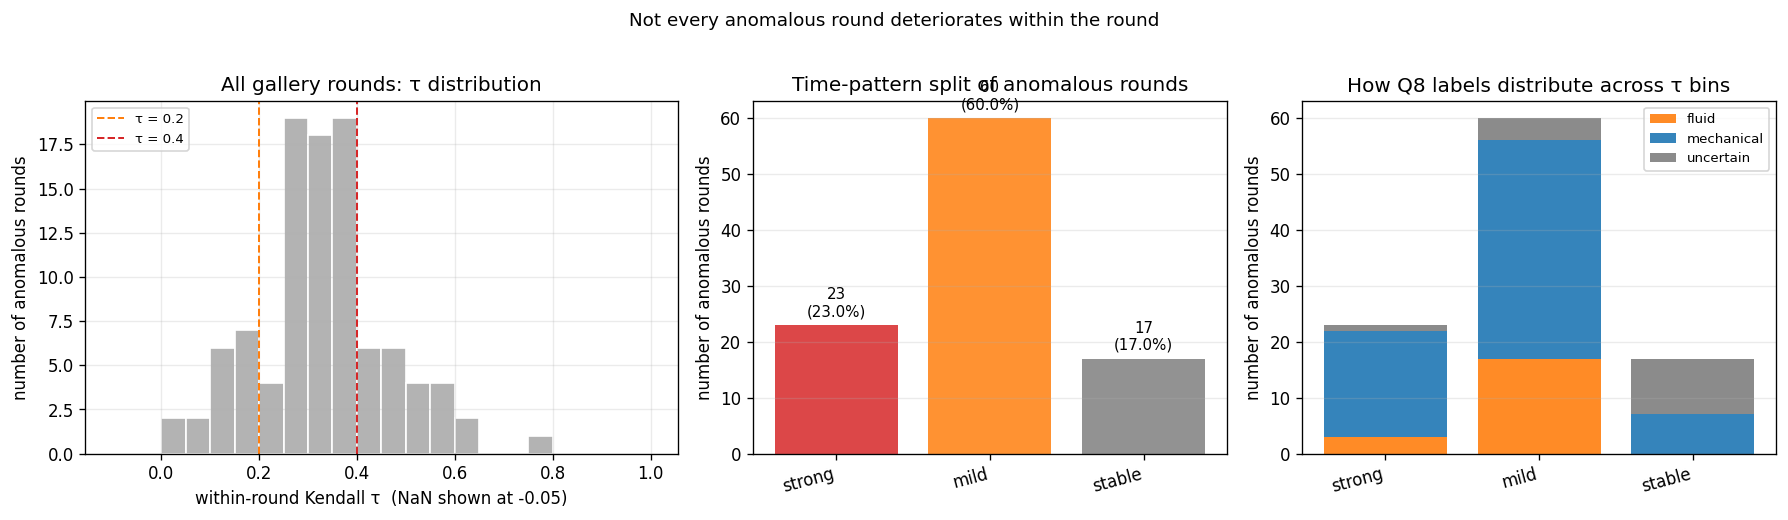

All anomalous rounds split by within-round trend:
                      n_rounds  pct_of_gallery
tau_band                                      
strong worsening            23            23.0
mild worsening              60            60.0
stable but anomalous        17            17.0

By Q8 category:
category              fluid  mechanical  uncertain
tau_band                                          
strong worsening          3          19          1
mild worsening           17          39          4
stable but anomalous      0           7         10

By era:
era                    0   1
tau_band                    
strong worsening       0  23
mild worsening        10  50
stable but anomalous  10   7


In [10]:
TAU_STRONG = 0.40
TAU_MILD   = 0.20

vis = gallery.copy()

def tau_band(v):
    if pd.isna(v) or v < TAU_MILD:
        return 'stable but anomalous'
    if v < TAU_STRONG:
        return 'mild worsening'
    return 'strong worsening'

band_order = ['strong worsening', 'mild worsening', 'stable but anomalous']
vis['tau_band'] = vis['tau'].apply(tau_band)
vis['tau_plot'] = vis['tau'].fillna(-0.05)

counts = vis['tau_band'].value_counts().reindex(band_order, fill_value=0)
pct = (100 * counts / len(vis)).round(1)
by_cat = (vis.groupby(['tau_band', 'category']).size()
             .unstack(fill_value=0)
             .reindex(band_order))
by_era = (vis.groupby(['tau_band', 'era']).size()
             .unstack(fill_value=0)
             .reindex(band_order))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={'width_ratios': [1.25, 1, 1]})

# (1) Tau histogram
ax = axes[0]
bins = np.linspace(-0.1, 1.0, 23)
ax.hist(vis['tau_plot'], bins=bins, color='0.7', edgecolor='white')
ax.axvline(TAU_MILD, color='tab:orange', lw=1.2, ls='--', label='τ = 0.2')
ax.axvline(TAU_STRONG, color='tab:red', lw=1.2, ls='--', label='τ = 0.4')
ax.set_xlabel('within-round Kendall τ  (NaN shown at -0.05)')
ax.set_ylabel('number of anomalous rounds')
ax.set_title('All gallery rounds: τ distribution')
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc='upper left')

# (2) Three-way split
ax = axes[1]
colors = ['tab:red', 'tab:orange', 'tab:gray']
ax.bar(range(len(band_order)), counts.values, color=colors, alpha=0.85)
for i, (n, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, n + 1, f'{n}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(band_order)))
ax.set_xticklabels(['strong', 'mild', 'stable'], rotation=15, ha='right')
ax.set_ylabel('number of anomalous rounds')
ax.set_title('Time-pattern split of anomalous rounds')
ax.grid(axis='y', alpha=0.25)

# (3) Composition by Q8 category
ax = axes[2]
cat_order = ['fluid', 'mechanical', 'uncertain']
cat_colors = {'fluid': 'tab:orange', 'mechanical': 'tab:blue', 'uncertain': 'tab:gray'}
bottom = np.zeros(len(band_order))
for cat in cat_order:
    vals = by_cat[cat].values if cat in by_cat.columns else np.zeros(len(band_order))
    ax.bar(range(len(band_order)), vals, bottom=bottom, color=cat_colors[cat], alpha=0.9, label=cat)
    bottom += vals
ax.set_xticks(range(len(band_order)))
ax.set_xticklabels(['strong', 'mild', 'stable'], rotation=15, ha='right')
ax.set_ylabel('number of anomalous rounds')
ax.set_title('How Q8 labels distribute across τ bins')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Not every anomalous round deteriorates within the round', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

print('All anomalous rounds split by within-round trend:')
print(pd.DataFrame({'n_rounds': counts, 'pct_of_gallery': pct.astype(float)}).to_string())
print('\nBy Q8 category:')
print(by_cat.to_string())
print('\nBy era:')
print(by_era.to_string())

_summary['tau_band'] = counts.to_dict()
_summary['tau_band_pct'] = pct.to_dict()


## 11. Validation note — the full check now lives in nb05

**Takeaway:** nb04 only uses era-specific near-normal references; the full validation of those references now lives in nb05.


The black reference curves used in §8 are **era-specific near-normal
surface-card baselines**, not physical ground-truth pump cards.  They are
constructed from trusted cards whose IF score lies below the within-era P50,
then aggregated as a point-wise median on recentered shapes.

The **full validation** of those references now lives in
`notebook05 §6`, where we compare each era reference against the Q9 KMeans
medoids, report the inlier-core cluster mix, and overlay the curves directly.

Short version:

- **Era 1** aligns cleanly with **cluster 0**.
- **Era 0** is built mostly from **cluster 2**, but its pointwise-median
  reference lies in the near-normal **0/2 corridor** rather than exactly on a
  single medoid.
- **Both** references are far from the anomaly basin (**cluster 1**).

So the two-baseline strategy used in nb04 is best read as an
**era-specific near-normal comparison baseline**, validated against the
independent Q9 taxonomy in nb05, rather than a claim of absolute correctness.